# 📊 Classification Model Comparison

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Train multiple classification algorithms.
- Compare their performance.
- Evaluate using multiple metrics.
- Understand when to choose each algorithm.
- Identify the strengths and weaknesses of each model.

In [1]:
import time
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        )
}

In [7]:
results = []

for name, model in models.items():

    start = time.time()

    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        prediction = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

    end = time.time()

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),

        "Precision": precision_score(
            y_test,
            prediction
        ),

        "Recall": recall_score(
            y_test,
            prediction
        ),

        "F1 Score": f1_score(
            y_test,
            prediction
        ),

        "Training Time (s)": round(end-start,4)
    })

In [8]:
comparison = pd.DataFrame(results)

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.0480
3,SVM,0.982456,0.986111,0.986111,0.986111,0.0122
1,KNN,0.956140,0.958904,0.972222,0.965517,3.4737
5,Random Forest,0.956140,0.958904,0.972222,0.965517,0.2471
7,XGBoost,0.956140,0.946667,0.986111,0.965986,0.3377
6,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,1.1927
2,Naive Bayes,0.938596,0.945205,0.958333,0.951724,0.0000
4,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.0190


In [9]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print(best_model.iloc[0])

Model                Logistic Regression
Accuracy                        0.982456
Precision                       0.986111
Recall                          0.986111
F1 Score                        0.986111
Training Time (s)                  0.048
Name: 0, dtype: object


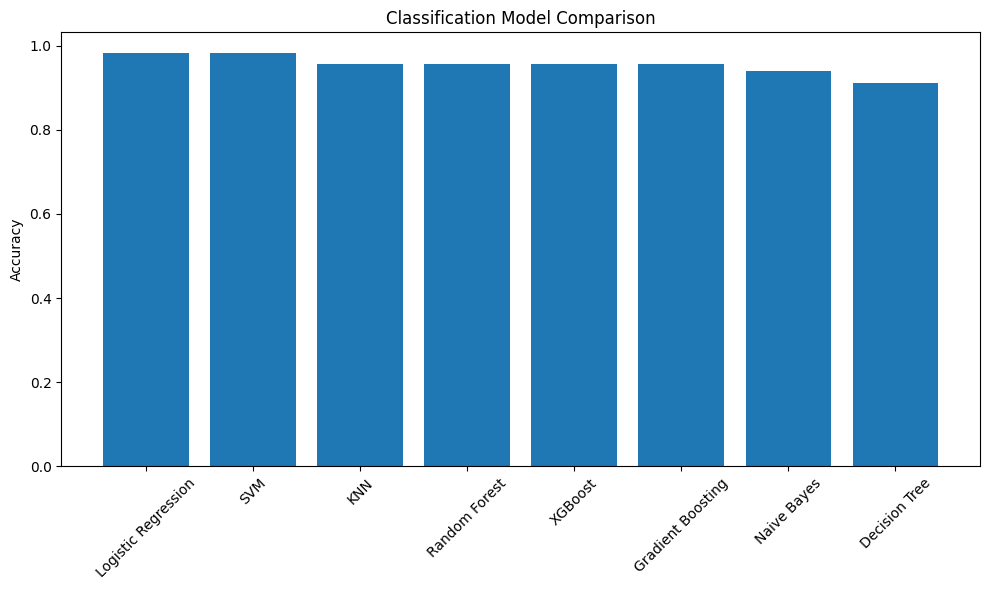

In [10]:
import matplotlib.pyplot as plt

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Classification Model Comparison")

plt.tight_layout()

plt.show()

## 📚 When Should You Use Each Model?

### Logistic Regression

- Baseline model
- Binary classification
- Interpretable predictions

---

### KNN

- Small datasets
- Simple decision boundaries

---

### Naive Bayes

- Text classification
- Spam detection
- Sentiment analysis

---

### SVM

- High-dimensional datasets
- Complex nonlinear boundaries

---

### Decision Tree

- Explainable models
- Rule-based systems

---

### Random Forest

- General-purpose classification
- High accuracy
- Reduced overfitting

---

### Gradient Boosting

- Structured/tabular datasets
- High predictive performance

---

### XGBoost

- Large datasets
- Kaggle competitions
- Production ML systems

## 🎯 Key Takeaways

- There is no universally best algorithm.
- The choice depends on the dataset and problem.
- Always compare multiple models.
- Evaluate using multiple metrics, not only accuracy.
- Consider model interpretability, speed, and scalability along with performance.